In [1]:
import os
import ctypes
import sys
from pathlib import Path

# --- 1. PATH native library setup ---
root = Path.cwd()

if sys.platform.startswith('linux'):
    lib_dir = root / 'pathlib' / 'lib_lnx'
    lib_name = 'pathwrap.so'
    path_lib_name = 'libpath50.so'
elif sys.platform == 'darwin':
    lib_dir = root / 'pathlib' / 'lib_osx'
    lib_name = 'pathwrap.dylib'
    path_lib_name = 'libpath50.dylib'
elif sys.platform.startswith('win'):
    lib_dir = root / 'pathlib' / 'lib_win'
    lib_name = 'pathwrap.dll'
    path_lib_name = 'libpath50.dll'
else:
    lib_dir = root / 'pathlib' / 'lib_lnx'
    lib_name = 'pathwrap.so'
    path_lib_name = 'libpath50.so'

pathwrap_path = root / lib_name

if not pathwrap_path.exists():
    print('Missing pathwrap library:', pathwrap_path)
    print('Build it with:')
    print('  gcc -shared -fPIC -Ipathlib/include -Ipathlib/examples/C -o pathwrap.so \\')
    print('    pathwrap.c pathlib/examples/C/Standalone_Path.c \\')
    print('    -Lpathlib/lib_lnx -lpath50 -lm -ldl')

# Preload PATH shared library BEFORE anything tries to use pathwrap
if lib_dir.exists():
    ld_path = os.environ.get('LD_LIBRARY_PATH', '')
    if str(lib_dir) not in ld_path:
        os.environ['LD_LIBRARY_PATH'] = f"{lib_dir}:{ld_path}" if ld_path else str(lib_dir)

if not os.environ.get('PATH_LICENSE_STRING'):
    os.environ['PATH_LICENSE_STRING'] = '1259252040&Courtesy&&&USR&GEN2035&5_1_2026&1000&PATH&GEN&31_12_2035&0_0_0&6000&0_0'


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from GridWorld import GridWorldEnv
from SRQagent import SRQAgent

In [ ]:
def train_experiment(n_episodes=1000, p_env=0.8, pathwrap_path=None):
    env = GridWorldEnv(p=p_env)
    
    pathwrap_path = pathwrap_path or str(globals().get("pathwrap_path", "pathwrap.so"))
    
    # Get environment dimensions
    num_agents = 2
    num_actions = len(env.action_space)
    
    # Initialize Agents with correct parameters
    agents = [
        SRQAgent(
            agent_id=0, 
            num_agents=num_agents,
            num_actions=num_actions,
            epsilon_robust=1.0,
            epsilon_explore=1.0,
            alpha=0.1,
            gamma=0.9,
            decay_rate=0.999,  
            pathwrap_path=pathwrap_path
        ),
        SRQAgent(
            agent_id=1,
            num_agents=num_agents,
            num_actions=num_actions,
            epsilon_robust=1.0,
            epsilon_explore=1.0,
            alpha=0.1,
            gamma=0.9,
            decay_rate=0.999,
            pathwrap_path=pathwrap_path
        )
    ]
    
    history_rewards = [[], []]
    
    print(f"Starting Training: {n_episodes} Episodes, p={p_env}")
    
    for ep in tqdm(range(n_episodes)):
        obs = env.reset()
        done = False
        ep_rewards = [0, 0]
        
        while not done:
            actions = [ag.act(obs) for ag in agents]
            next_obs, rewards, done, _ = env.step(actions)
            
            for ag in agents:
                ag.update(obs, actions, rewards, next_obs)
                
            obs = next_obs
            ep_rewards[0] += rewards[0]
            ep_rewards[1] += rewards[1]
            
        history_rewards[0].append(ep_rewards[0])
        history_rewards[1].append(ep_rewards[1])
        print(f"Episode {ep + 1} reward: {ep_rewards}")
        
        for ag in agents:
            ag.decay_parameters()
            
    return history_rewards

rewards_data = train_experiment(n_episodes=100, p_env=0.8)

Loading PATH wrapper from /homes/jhl323/SRE-DQN/pathwrap.so...
PATH Solver Ready.
Loading PATH wrapper from /homes/jhl323/SRE-DQN/pathwrap.so...
PATH Solver Ready.
Starting Training: 10 Episodes, p=0.8


 10%|█         | 1/10 [00:06<00:55,  6.14s/it]

Episode 1 reward: [-445, -417]


 20%|██        | 2/10 [00:15<01:05,  8.17s/it]

Episode 2 reward: [-129, -174]


...

Episode 8 reward: [-63, -9]


 90%|█████████ | 9/10 [01:01<00:06,  6.46s/it]

Episode 9 reward: [97, 88]


100%|██████████| 10/10 [01:13<00:00,  7.33s/it]

Episode 10 reward: [-205, -272]


ValueError: x and y must have same first dimension, but have shapes (0,) and (41,)

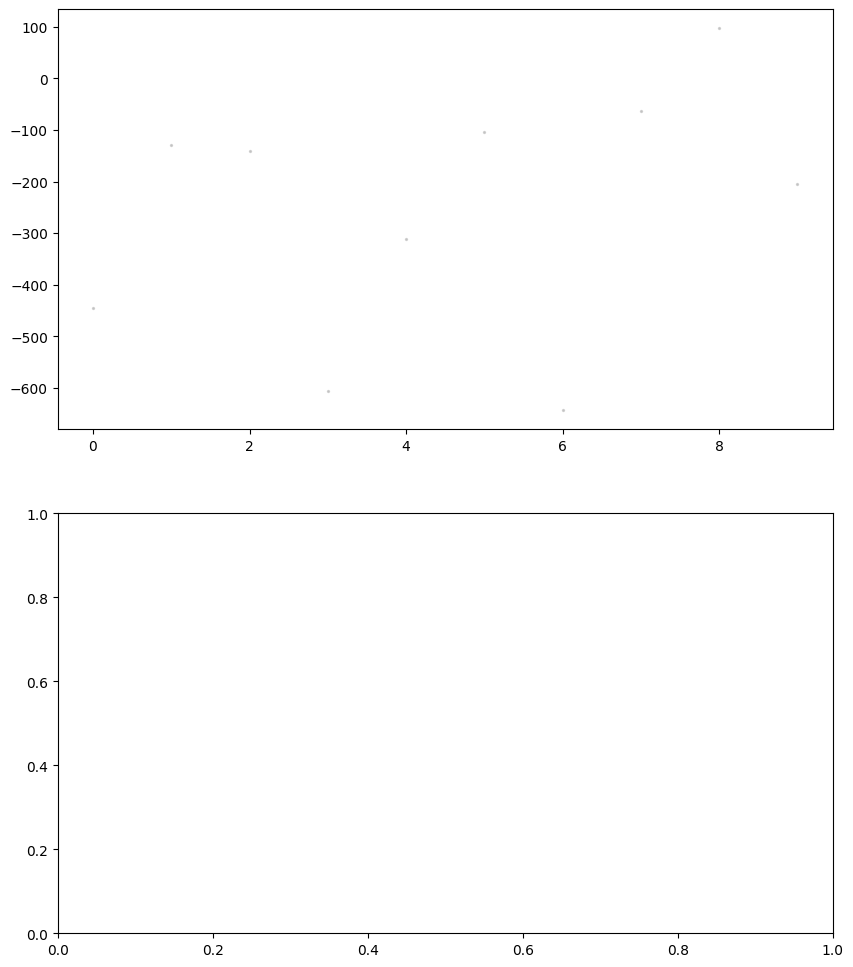

In [4]:
def plot_results(rewards, window=50, out_path="results.png"):
    fig, axes = plt.subplots(2, 1, figsize=(10, 12))
    
    for agent_id in [0, 1]:
        ax = axes[agent_id]
        data = rewards[agent_id]
        
        # Raw Data (scatter)
        ax.scatter(range(len(data)), data, s=2, alpha=0.3, color='gray', label='Episode Reward')
        
        # Rolling Average
        rolling_mean = np.convolve(data, np.ones(window)/window, mode='valid')
        ax.plot(range(window-1, len(data)), rolling_mean, linewidth=2, color='blue', label=f'Rolling Avg ({window})')
        
        # Statistics (Last 100 episodes)
        # last_100 = data[-100:]
        # mean_val = np.mean(last_100)
        # std_val = np.std(last_100)
        last_10 = data[-10:]
        mean_val = np.mean(last_10)
        std_val = np.std(last_10)
        
        ax.axhline(mean_val, color='red', linestyle='--', label=f'Final Mean: {mean_val:.2f}')
        
        ax.set_title(f"Agent {agent_id+1} Rewards (SRQ)")
        ax.set_xlabel("Episode")
        ax.set_ylabel("Total Reward")
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    fig.savefig(out_path, dpi=300, bbox_inches="tight")  # save to file
    plt.show()

plot_results(rewards_data)